# Week 06: Stats for Business: Is the Price Right?

You just joined the pricing team at a car-listing marketplace. Your manager has a few questions and one rule: **every claim needs a number, and every number needs a reason to trust it.**

**Data:** `cars.csv`: about 12,000 car trims (1990–2017) with specs and sticker price (MSRP). Source: [Car Features and MSRP (Kaggle)](https://www.kaggle.com/datasets/CooperUnion/cardataset). It's real data, so it's messy.

**What you'll practice** (all from this week's lecture):
- Cleaning before describing
- Mean vs median, skew, log transforms
- z-scores
- Bootstrap confidence intervals
- One- and two-sample tests, and picking the right one
- Confounding, and significant vs important

**How to answer:** Fill in the code cells, then write 1–3 sentences in each **Answer:** cell. Code without an interpretation is only half the job.

Plan for about 2–3 hours. 🚀 questions are optional stretch.

## Setup

In [ ]:
# run this first if you dont have them installed in your env
!pip install pandas numpy matplotlib scipy

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", None)
rng = np.random.default_rng(42)  # use rng for all random sampling so your results are reproducible

df = pd.read_csv("data/cars.csv")
print(df.shape)
df.head()

(11914, 15)


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,18,3916,34500


---
## Part 1: Can you trust this data?

### Q1. Find the problems before you average anything

This dataset has **at least five** real problems. Find them, fix or flag each one, and build a cleaned DataFrame called `clean`. You'll use `clean` for the rest of the notebook.

Use your Week 02 cleaning checklist. Some nudges, in no particular order:
- Count things twice.
- The most common value in a column can be more suspicious than the largest one.
- Would you print every max value in a sales brochure?
- Missing values usually have a reason. *Who* is missing?
- Is every number in a column measured in the same unit?
- Does every column vary at the level you'd expect?
- Not everything weird is wrong.

For each problem, decide: **drop it, set it to NaN, flag it, or leave it**. Dropping whole rows is the last resort, because a row with a bad price may still have a good MPG.

In [99]:
# Explore here. Add as many cells as you need.
# Useful: .duplicated(), .value_counts(), .describe(), .isna().sum(), .nlargest(), .groupby(...).nunique()

# df.info()
# df.dtypes
# df.isna().sum()
# df.value_counts()
# df.describe()
# df.nlargest(5, 'highway MPG')
# df.duplicated().sum()
# df.groupby("highway MPG").nunique()
# df.nlargest(5, 'Year')
# df.groupby("Number of Doors").nunique()
# df.groupby("Transmission Type").nunique()
# df.MSRP.value_counts()
# df["Transmission Type"].value_counts()
# df.groupby("Transmission Type")[df["Transmission Type"] == "UNKNOWN"].value_counts()

**Cleaning log:** fill in one row per problem.

| # | Problem | How I found it | Rows affected | What I did | Why |
|---|---|---|---|---|---|
| 1 | Duplicate Rows | df.duplicated().sum() | 720 | Dropped them | duplicates are not needed |
| 2 | Missing values in engine HP, Engine Cylinders, Number of Doors, and Engine Fuel Type  | df.isna().sum() | 102 | left them alone | these values can be inferred based off of the model |
| 3 | Some tranmission type values are unknown | df["Transmission Type"].value_counts() | 19 | change them to NaN | to keep the rest of the data intact |
| 4 | highest MPG is 354 when mean is 26 | df.nlargest(5, 'highway MPG') | 1 | set to NaN | value must be a typo |
| 5 | MSRP Placeholders | df.MSRP.value_counts()| 1036 | drop values | better to get rid of it for price analysis|

In [82]:
# Build your cleaned DataFrame. Start from a copy so df stays untouched.
clean = df.copy()
clean.columns = clean.columns.str.strip().str.lower().str.replace(" ", "_") # freebie: snake_case names
clean = clean.drop_duplicates() # drop duplicates
clean.loc[clean["highway_mpg"] > 200, "highway_mpg"] = pd.NA
clean["transmission_type"] = clean["transmission_type"].replace("UNKNOWN", pd.NA) 
clean = clean[clean["msrp"] != 2000]


In [115]:
# Checkpoint: run this before moving on.
print(clean.shape)
print(clean.isna().sum()[clean.isna().sum() > 0])
clean["msrp"].value_counts()
# Fewer than ~10,000 rows? You probably dropped too much. Go back and use NaN or a flag instead.

(10447, 16)
engine_fuel_type         3
engine_hp               69
engine_cylinders        30
transmission_type        7
number_of_doors          6
highway_mpg              1
highway_mpg_z_scores     1
dtype: int64


msrp
29995    18
25995    17
27995    15
20995    15
21995    14
         ..
59475     1
54425     1
51525     1
50920     1
50620     1
Name: count, Length: 6048, dtype: int64

---
## Part 2: Describe

### Q2. What does a "typical" car cost?

Your manager wants one number for "typical price" on the homepage.

a) Compute the mean and median MSRP. Which is bigger, and why?

b) Plot a histogram of MSRP, then a histogram of `np.log10(msrp)`. Describe each shape in a few words.

c) What percent of cars cost more than the mean?

d) Which number belongs on the homepage? Why?

Mean:   $44,789
Median: $31,870


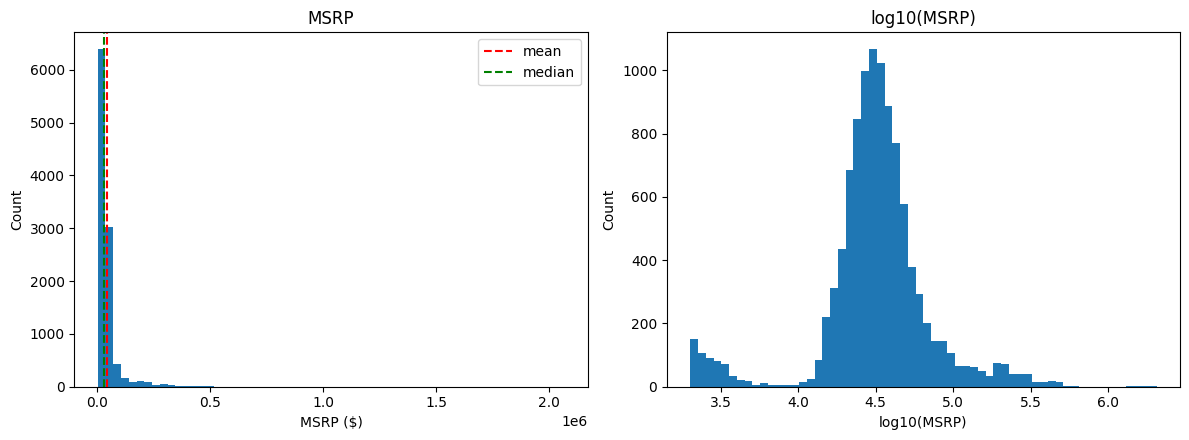

np.float64(24.447209725279983)

In [118]:
# a) mean and median
mean_msrp = clean["msrp"].mean()
median_msrp = clean["msrp"].median()
print(f"Mean:   ${mean_msrp:,.0f}")
print(f"Median: ${median_msrp:,.0f}")

# b) two histograms side by side (plt.subplots(1, 2))
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

# histogram 1
ax[0].hist(clean["msrp"], bins=60)
ax[0].axvline(mean_msrp, color="red", linestyle="--", label="mean")
ax[0].axvline(median_msrp, color="green", linestyle="--", label="median")
ax[0].set_title("MSRP")
ax[0].set_xlabel("MSRP ($)")
ax[0].set_ylabel("Count")
ax[0].legend()

# histogram 2
ax[1].hist(np.log10(clean["msrp"]), bins=60)
ax[1].set_title("log10(MSRP)")
ax[1].set_xlabel("log10(MSRP)")
ax[1].set_ylabel("Count")


plt.tight_layout()
plt.show()

# c) share of cars above the mean
(clean["msrp"] > clean["msrp"].mean()).sum() / len(clean)*100

**Answer:** The homepage should have the median since the mean may be skewed by the bottom values.

### Q3. Fuel-efficient *for its size*?

Two 2017 cars:
- **Honda Civic** (Compact): 42 highway MPG
- **Volvo S90** (Large): 34 highway MPG

The Civic wins on raw MPG, but large cars are heavier. Which one is more impressive *for its class*?

a) For 2017 cars (only the MPG values you trust after Q1), compute the mean and standard deviation of highway MPG for each `vehicle_size`.

b) Compute each car's z-score within its own size class.

c) Which is more fuel-efficient for its class? How unusual is each one?

In [ ]:
# a) mean and std of highway_mpg by vehicle_size, 2017 only
clean_2017 = clean[clean["year"] == 2017]
clean_2017.groupby("vehicle_size")["highway_mpg"].agg(["mean", "std"])

# b) z = (value - class mean) / class std

# a) Mean and standard deviation of trusted highway MPG by vehicle size, 2017 only
clean_2017 = clean[clean["year"] == 2017]
mpg_summary = clean_2017.groupby("vehicle_size")["highway_mpg"].agg(["mean", "std"])
display(mpg_summary)

# b) Z-scores within each car's size class
honda_z = (42 - mpg_summary.loc["Compact", "mean"]) / mpg_summary.loc["Compact", "std"]
volvo_z = (34 - mpg_summary.loc["Large", "mean"]) / mpg_summary.loc["Large", "std"]

print(f"Honda Civic z-score: {honda_z:.2f}")
print(f"Volvo S90 z-score: {volvo_z:.2f}")
("Honda Civic" - stats.loc["Compact", "mean"]) / stats.loc["Compact", "std"]

AttributeError: module 'scipy.stats' has no attribute 'loc'

**Answer:**

---
## Part 3: Uncertainty

### Q4. How sure are we about the median price?

The 2017 cars are one snapshot of the market. With a slightly different set of cars, the median would move. A bootstrap shows how much.

a) Compute the median MSRP of 2017 cars.

b) Bootstrap it: resample the 2017 prices **with replacement** 5,000 times and take the median each time. Plot the 5,000 medians and report the 95% interval (2.5th and 97.5th percentiles).

c) Repeat for 2017 cars from **one make** with fewer than 50 cars that year (your choice). Is the interval wider or narrower? Why?

d) Explain the interval from (b) in one sentence a manager would understand.

In [ ]:
def bootstrap_median(values, n_boot=5000):
    """Return an array of n_boot bootstrap medians."""
    # hint: rng.choice(values, size=len(values), replace=True)
    pass

# a, b)

# c)

**Answer:**

---
## Part 4: Testing

### Q5. Can marketing say "our 2017 compacts average over 30 MPG"?

a) Write H₀ and Hₐ. One-sided or two-sided? Why?

b) How many cars are in the sample, and what does the distribution look like? Is a t-test reasonable here?

c) Run a one-sample t-test at α = 0.05 (`stats.ttest_1samp(..., alternative="greater")`). State the conclusion in plain English.

d) **Independence check.** Tests assume each row is an independent observation. Count how many rows each `make` + `model` has in this sample. Then average to one row per model and rerun the test. What changed, and which version do you trust more?

In [ ]:
# b) sample: 2017 compact cars (MPG you trust); n, mean, histogram

# c) one-sample t-test vs 30

# d) rows per make+model, then one row per model and retest

**Answer:**

### Q6. Do manual cars cost less? (the big one)

A sales rep says: *"Manual cars are way cheaper. We should push manuals to budget shoppers."*

Compare `AUTOMATIC` vs `MANUAL` only.

a) Compare the median MSRP of the two groups.

b) Before believing it, compare the `year` of manual vs automatic cars. What do you notice?

c) Redo (a) using only 2015–2017 cars, then within each `vehicle_size`. For 2015–17 compacts, use the Mann–Whitney U test (`stats.mannwhitneyu(auto, manual)`) to compare prices.

- What do the p-value and medians suggest?

d) Write one sentence back to the sales rep.

In [122]:
# a) compare median MSRP by transmission type
clean.groupby("transmission_type")["msrp"].median()
# b) compare year by transmission type
clean.groupby("transmission_type")["year"].median()
# c) compare 2015-2017 medians overall and within each vehicle_size
auto = clean[(clean["year"] >= 2015) & (clean["year"] <= 2017)]
manual = clean[(clean["year"] >= 2015) & (clean["year"] <= 2017)]
# For 2015-17 compacts, test automatic vs manual prices with:
stats.mannwhitneyu(auto, manual)

TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

**Answer:**

### Q7. Significant ≠ important

Among cars whose MPG you trust, 4-door cars get better highway MPG than 2-door cars.

a) Run a Welch t-test. Report the difference in means and the p-value.

b) Translate the difference into dollars. Assume 12,000 miles/year and \$3.50/gallon. How much does the average 4-door driver save per year?

c) Now pretend you only had **30 cars per group.** Draw 30 random 4-door and 30 random 2-door cars, run the same test, and repeat 1,000 times. What fraction of those tests come out significant (p < 0.05)?

d) Would you put "4-door cars are significantly more fuel-efficient" in an ad? What would you say instead?

In [ ]:
# a) Welch t-test, 4-door vs 2-door
clean_2017 = clean[clean["year"] == 2017]   
# b) yearly gas cost = miles * price_per_gallon / mpg

# c) simulation
n_sims, hits = 1000, 0
for _ in range(n_sims):
    # sample 30 from each group with rng.choice(..., 30, replace=False), run the test, count p < 0.05
    pass

**Answer:**

---
## Part 5: Communicate

### Q8. Your memo to the pricing manager

Write 4–6 sentences. Include:
- Your answer to "do manual cars cost less?", with at least one number
- One other finding from this notebook that matters for pricing
- One limitation of this data a manager should know about

No unexplained jargon: if you say "significant," say what it means.

**Memo:**

---
## 🚀 Stretch (optional)

### 🚀 S1. Horsepower and price

a) Compute the correlation between `engine_hp` and `msrp` three ways: Pearson, Pearson with `np.log10(msrp)`, and Spearman. Why do they differ?

b) Scatter plot HP vs MSRP with a log y-axis (`plt.yscale("log")`).

c) Does adding horsepower *cause* a higher price? Name one lurking variable.

In [ ]:
# S1

### 🚀 S2. Is transmission tied to vehicle size?

For 2015–2017 cars (automatic and manual only), build a crosstab of `vehicle_size` × `transmission_type` and run a chi-square test (`stats.chi2_contingency`). How does this connect to Q6?

In [ ]:
# S2